# **Importing Libraries**

In [3]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import holidays
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
from tensorflow.keras.layers import Layer
from tensorflow.keras.metrics import Mean
from tqdm import tqdm
import joblib
import os

# **Data Loading**

In [4]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'

df = pd.read_csv(csv_url)

# **EDA**

## Summmary

In [5]:
df

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,7.443489e+04,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,4.468732e+04,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,8.054617e+04,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,9.033153e+04,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,1.034058e+05,49.182064,-46.425379,87.578086,2.424654
...,...,...,...,...,...,...,...
53145,2023-10-19 19:00:00,28750.75,2.984059e+07,53.630054,109.926882,129.065981,7.459700
53146,2023-10-19 20:00:00,28715.38,4.997623e+07,53.531282,111.721905,129.268969,7.118597
53147,2023-10-19 21:00:00,28604.09,3.205666e+07,53.221944,113.055031,129.287930,6.210037
53148,2023-10-19 22:00:00,28649.65,2.200420e+07,53.332673,114.513131,129.219782,6.515616


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


In [7]:
# Mengubah kolom 'Date' menjadi tipe datetime dengan format YYYY-MM-DD HH:MM:SS
# Kita menggunakan errors='coerce' untuk menangani format yang mungkin tidak konsisten
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Menjadikan kolom 'Date' sebagai index DataFrame
df = df.set_index('Date')
display(df)

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00,3860.00,7.443489e+04,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00,3871.48,4.468732e+04,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00,3864.95,8.054617e+04,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00,3858.08,9.033153e+04,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00,3856.67,1.034058e+05,49.182064,-46.425379,87.578086,2.424654
...,...,...,...,...,...,...
2023-10-19 19:00:00,28750.75,2.984059e+07,53.630054,109.926882,129.065981,7.459700
2023-10-19 20:00:00,28715.38,4.997623e+07,53.531282,111.721905,129.268969,7.118597
2023-10-19 21:00:00,28604.09,3.205666e+07,53.221944,113.055031,129.287930,6.210037


In [8]:
df.describe()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
count,53150.000000,5.315000e+04,53150.000000,53150.000000,53150.000000,53150.000000
mean,20595.357333,6.919215e+07,50.403605,0.528272,221.733334,0.229762
std,15822.296994,1.059041e+08,3.210682,353.293188,208.401440,5.168655
min,3172.050000,0.000000e+00,35.178834,-1885.690630,17.436266,-31.767152
25%,7976.915000,1.012558e+07,48.294197,-115.601600,72.702488,-2.717470
50%,13878.095000,2.766119e+07,50.038483,10.154419,128.787616,-0.032747
75%,29646.720000,8.944278e+07,52.406274,122.367509,325.616826,3.162442
max,68633.690000,3.005634e+09,64.657108,1430.405758,1004.531407,39.740297


## Stationary Test

In [9]:
def adf_test(series):
    result = adfuller(series, autolag='AIC')

    print("ADF Test Results:")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Data stasioner")
    else:
        print("Data tidak stasioner")

adf_test(df['Close'])

ADF Test Results:
ADF Statistic: -1.5594011394616063
p-value: 0.503948923725749
Data tidak stasioner


## Decomposition

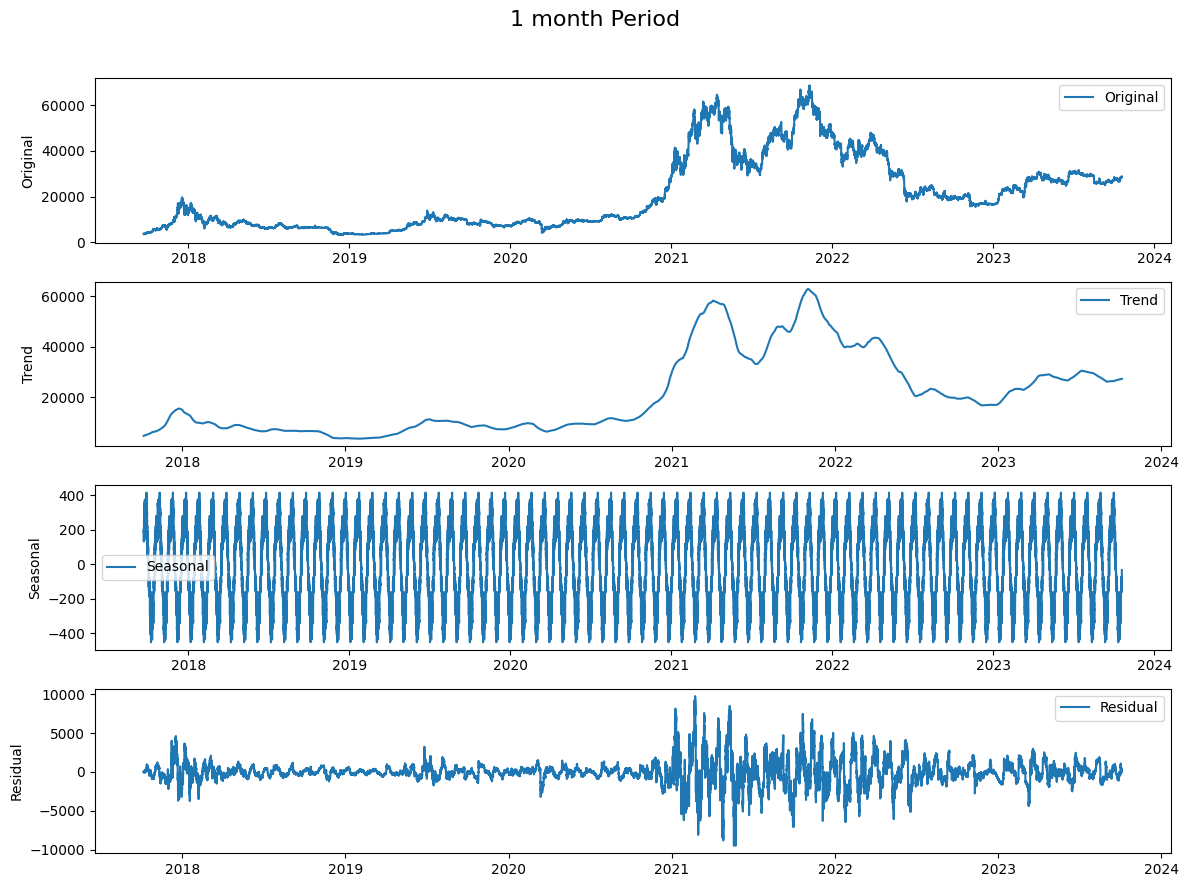

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Close'], period=720, model='additive')
# karena observasi dataset setiap jam, maka 1 hari = 24 jam, 720 jam = 30 hari

components = {
    'Original': df['Close'],
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
}

plt.figure(figsize=(12, 9))
plt.suptitle("1 month Period", fontsize=16)
# asumsi 1 bulan = 30 hari

for i, (title, series) in enumerate(components.items(), start=1):
    plt.subplot(4, 1, i)
    plt.plot(df.index, series, label=title)
    plt.legend(loc='best')
    plt.ylabel(title)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Lag Analysis

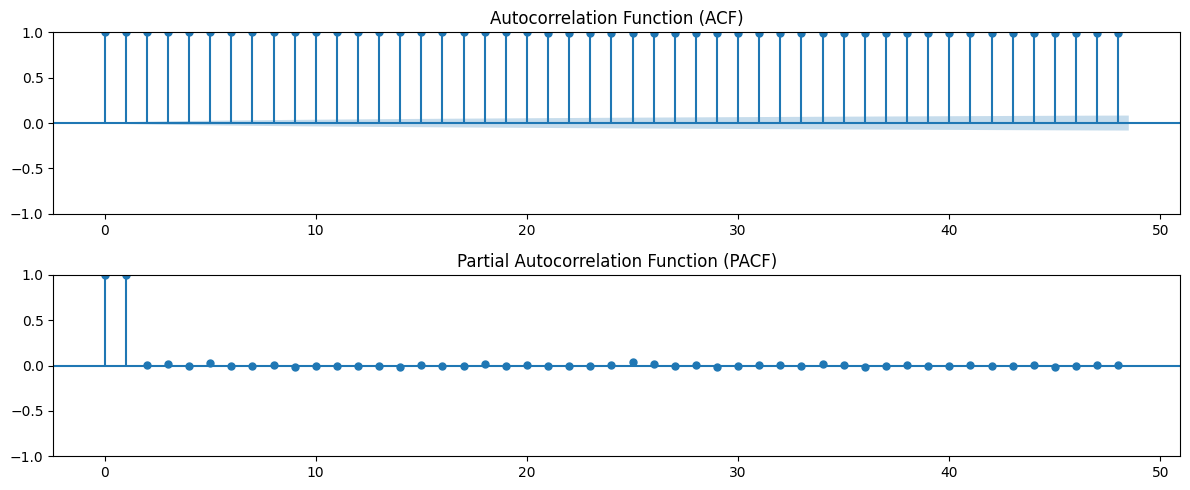

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(211)
plot_acf(df['Close'], lags=48, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

plt.subplot(212)
plot_pacf(df['Close'], lags=48, ax=plt.gca())
plt.title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

## Correlation Analysis

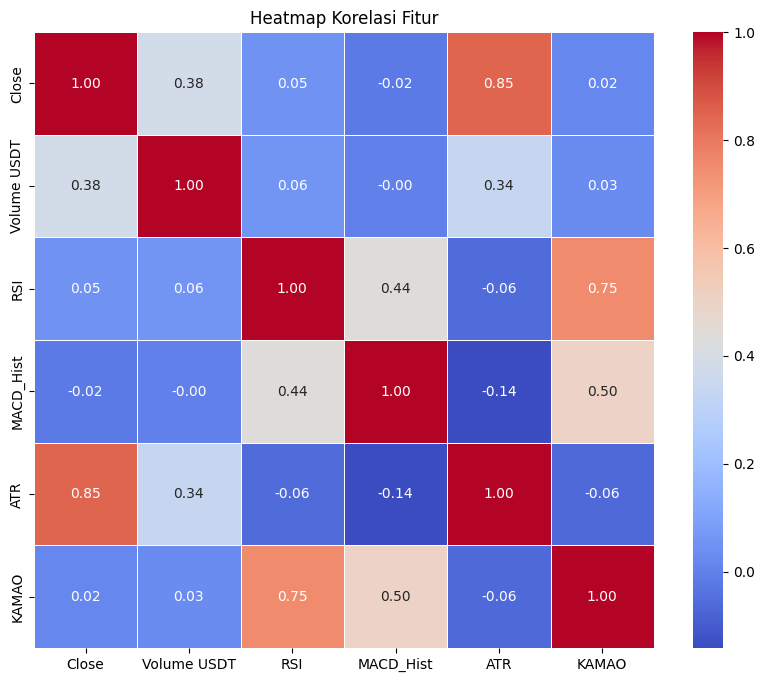

In [12]:
# Menghitung matriks korelasi antar kolom numerik
corr_matrix = df.corr()

# Membuat visualisasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur')
plt.show()

Berdasarkan heatmap diatas, dapat disimpulkan bawha 4 fitur yang memiliki korelasi terbesar dengan target (Close) secara berturut-turut adalah Close itu sendiri sebesar 1.00, ATR sebesar 0.85, Volume USDT sebesar 0.38, dan RSI sebesar 0.05

In [13]:
df = df[["Close", "ATR", "Volume USDT", "RSI"]]
df

,Close,ATR,Volume USDT,RSI
Date,,,,
2017-09-21 09:00:00,3860.00,88.054720,7.443489e+04,49.192454
2017-09-21 10:00:00,3871.48,87.996283,4.468732e+04,49.233202
2017-09-21 11:00:00,3864.95,87.897128,8.054617e+04,49.210685
2017-09-21 12:00:00,3858.08,87.720856,9.033153e+04,49.186948
2017-09-21 13:00:00,3856.67,87.578086,1.034058e+05,49.182064
...,...,...,...,...
2023-10-19 19:00:00,28750.75,129.065981,2.984059e+07,53.630054
2023-10-19 20:00:00,28715.38,129.268969,4.997623e+07,53.531282
2023-10-19 21:00:00,28604.09,129.287930,3.205666e+07,53.221944


# **Preprocessing**

## Feature Engineering

### Rolling Statistics

In [14]:
window_size = 720
df = df.copy() # Explicitly work on a copy to avoid SettingWithCopyWarning
df['close_rolling_mean'] = df['Close'].rolling(window=window_size).mean()
df['close_rolling_std'] = df['Close'].rolling(window=window_size).std()
df['close_rolling_min'] = df['Close'].rolling(window=window_size).min()
df['close_rolling_max'] = df['Close'].rolling(window=window_size).max()

# Isi nilai NaN di awal data
df.fillna(0, inplace=True)

df.head()

,Close,ATR,Volume USDT,RSI,close_rolling_mean,close_rolling_std,close_rolling_min,close_rolling_max
Date,,,,,,,,
2017-09-21 09:00:00,3860.00,88.054720,74434.891166,49.192454,0.0,0.0,0.0,0.0
2017-09-21 10:00:00,3871.48,87.996283,44687.318944,49.233202,0.0,0.0,0.0,0.0
2017-09-21 11:00:00,3864.95,87.897128,80546.171672,49.210685,0.0,0.0,0.0,0.0
2017-09-21 12:00:00,3858.08,87.720856,90331.531390,49.186948,0.0,0.0,0.0,0.0
2017-09-21 13:00:00,3856.67,87.578086,103405.818040,49.182064,0.0,0.0,0.0,0.0


Ukuran windows yang besar ini berdasarkan grafik dekomposisi sebelumnya, tren musiman baru dapat terlihat dalam jangka waktu 1 bulan (720 jam).

### Lag Features

In [15]:
df['close_lag_1'] = df['Close'].shift(1)

# Isi nilai NaN di awal data
df.fillna(0, inplace=True)

lag 1 dipilih karena berdasarkan hasil PACF, hanya lag 1 yang secara individual paling memengaruhi nilai di masa depan

### Time-based Feature

In [16]:
# Buat kamus hari libur dari negara Indonesia
hari_libur_indonesia = holidays.Indonesia()

# Buat Time-based Features berdasarkan kamus hari libur
df['holiday'] = df.index.to_series().apply(lambda tanggal: tanggal in hari_libur_indonesia)

# Buat Time-based Features menggunakan aksesor .dt
df['day_of_week'] = df.index.dayofweek # Senin=0, Minggu=6
df['day_of_month'] = df.index.day
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['month_start'] = df.index.is_month_start
df['weekend'] = df.index.dayofweek >= 5

In [17]:
df

,Close,ATR,Volume USDT,RSI,close_rolling_mean,close_rolling_std,close_rolling_min,close_rolling_max,close_lag_1,holiday,day_of_week,day_of_month,week_of_year,month_start,weekend
Date,,,,,,,,,,,,,,,
2017-09-21 09:00:00,3860.00,88.054720,7.443489e+04,49.192454,0.000000,0.000000,0.00,0.00,0.00,True,3,21,38,False,False
2017-09-21 10:00:00,3871.48,87.996283,4.468732e+04,49.233202,0.000000,0.000000,0.00,0.00,3860.00,True,3,21,38,False,False
2017-09-21 11:00:00,3864.95,87.897128,8.054617e+04,49.210685,0.000000,0.000000,0.00,0.00,3871.48,True,3,21,38,False,False
2017-09-21 12:00:00,3858.08,87.720856,9.033153e+04,49.186948,0.000000,0.000000,0.00,0.00,3864.95,True,3,21,38,False,False
2017-09-21 13:00:00,3856.67,87.578086,1.034058e+05,49.182064,0.000000,0.000000,0.00,0.00,3858.08,True,3,21,38,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-19 19:00:00,28750.75,129.065981,2.984059e+07,53.630054,27230.548931,656.206274,26063.09,28750.75,28646.98,False,3,19,42,False,False
2023-10-19 20:00:00,28715.38,129.268969,4.997623e+07,53.531282,27232.673847,658.532988,26063.09,28750.75,28750.75,False,3,19,42,False,False
2023-10-19 21:00:00,28604.09,129.287930,3.205666e+07,53.221944,27234.646653,660.510628,26063.09,28750.75,28715.38,False,3,19,42,False,False


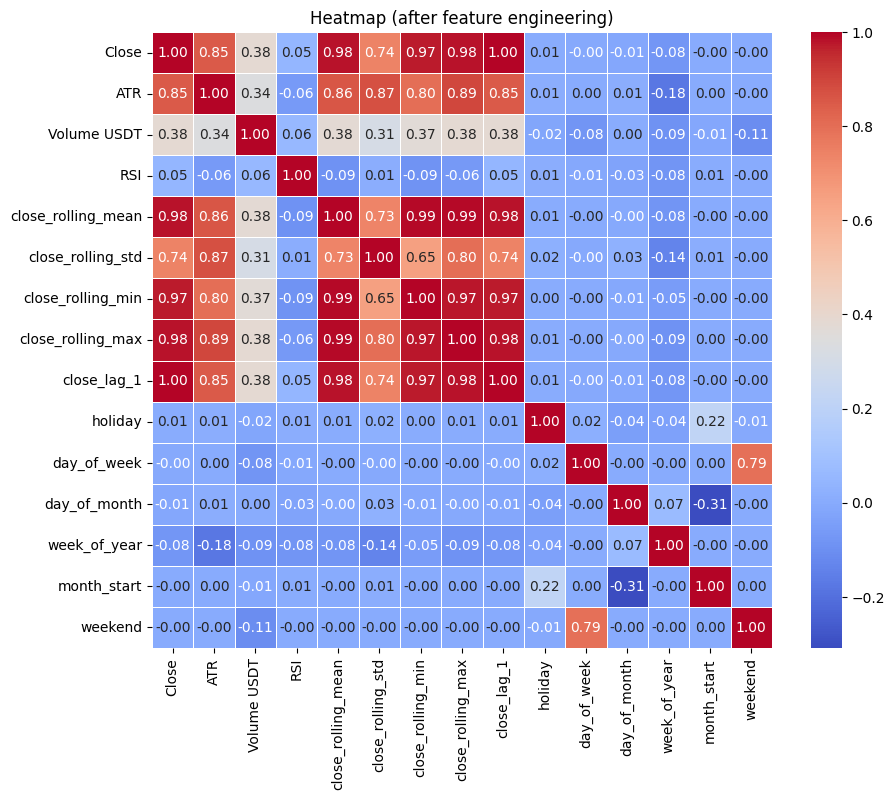

In [18]:
# Menghitung matriks korelasi antar kolom numerik
corr_matrix = df.corr()

# Membuat visualisasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap (after feature engineering)')
plt.show()

Setelah ada fitur-fitur tambahan dari proses feature engineering, terdapat lebih banyak fitur yang memiliki korelasi yang kuat dengan target. Berikut fitur-fitur yang akan digunakan untuk pelatihan model:

- Close, score: 1.00

- close_lag_1, score: 1.00

- close_rolling_max, score: 0.98

- close_rolling_mean, score: 0.98

- close_rolling_min, score: 0.97

- ATR, score: 0.85

- close_rolling_std, score: 0.74

- Volume USDT, score: 0.38

In [19]:
df = df[["Close", "close_lag_1", "close_rolling_max", "close_rolling_mean", "close_rolling_min", "ATR", "close_rolling_std", "Volume USDT"]]

## Train Test Split

In [20]:
# Split data 80% train, 10% validation, 10% test
n = len(df)
train_df = df[0:int(n*0.80)]
val_df = df[int(n*0.80):int(n*0.90)]
test_df = df[int(n*0.90):]

## Scaling

In [21]:
# Scaler for all features
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

In [22]:
train_scaled

array([[1.05092081e-02, 0.00000000e+00, 0.00000000e+00, ...,
        7.15416896e-02, 0.00000000e+00, 2.47651242e-05],
       [1.06845780e-02, 5.62406014e-02, 0.00000000e+00, ...,
        7.14824889e-02, 0.00000000e+00, 1.48678528e-05],
       [1.05848249e-02, 5.64078662e-02, 0.00000000e+00, ...,
        7.13820370e-02, 0.00000000e+00, 2.67983995e-05],
       ...,
       [3.04320668e-01, 3.35557945e-01, 3.58093671e-01, ...,
        2.34967474e-01, 1.56492989e-01, 2.24626913e-02],
       [3.04435850e-01, 3.36472948e-01, 3.58093671e-01, ...,
        2.34590190e-01, 1.56254718e-01, 3.15643070e-02],
       [3.02707662e-01, 3.36582806e-01, 3.58093671e-01, ...,
        2.34464704e-01, 1.56001913e-01, 3.35558440e-02]])

In [23]:
val_scaled

array([[0.29974058, 0.33493449, 0.35809367, ..., 0.23477681, 0.15570735,
        0.05494447],
       [0.29986294, 0.33210454, 0.35809367, ..., 0.23449218, 0.15540066,
        0.0410477 ],
       [0.29948287, 0.33222125, 0.35809367, ..., 0.2341382 , 0.15504254,
        0.03818721],
       ...,
       [0.26282308, 0.29645368, 0.36531141, ..., 0.13953004, 0.14698633,
        0.06488584],
       [0.26290405, 0.29689326, 0.36531141, ..., 0.13927301, 0.147288  ,
        0.07537255],
       [0.26357238, 0.29697048, 0.36531141, ..., 0.13905842, 0.14757947,
        0.05253659]])

In [24]:
test_scaled

array([[0.26387026, 0.29760792, 0.36531141, ..., 0.13883718, 0.14784983,
        0.07678999],
       [0.26288984, 0.29789204, 0.36531141, ..., 0.13876128, 0.14813597,
        0.09432122],
       [0.26293108, 0.29695693, 0.36531141, ..., 0.13858819, 0.14842694,
        0.08137141],
       ...,
       [0.38850295, 0.41838607, 0.41890142, ..., 0.11331397, 0.07425555,
        0.01066553],
       [0.38919893, 0.41676457, 0.41890142, ..., 0.11324493, 0.0744911 ,
        0.00732099],
       [0.39017751, 0.41742838, 0.41890142, ..., 0.11311953, 0.07474741,
        0.00585001]])

## Data Windowing

### For LSTM

In [25]:
INPUT_LENGTH = 720
OUTPUT_LENGTH = 24
TOTAL_LENGTH = INPUT_LENGTH + OUTPUT_LENGTH
BATCH_SIZE = 128

# Fungsi untuk membuat window
def create_window(data, input_length, output_length, total_length):
    X, y = [], []
    for i in range(len(data) - total_length + 1):
        X.append(data[i : i + input_length, :])
        y.append(data[i + input_length : i + total_length, 0])
    return np.array(X), np.array(y)

# Buat window untuk setiap set data
X_train, y_train = create_window(train_scaled, INPUT_LENGTH, OUTPUT_LENGTH, TOTAL_LENGTH)
X_val, y_val = create_window(val_scaled, INPUT_LENGTH, OUTPUT_LENGTH, TOTAL_LENGTH)
X_test, y_test = create_window(test_scaled, INPUT_LENGTH, OUTPUT_LENGTH, TOTAL_LENGTH)

In [26]:
# Mengonversi NumPy arrays menjadi float32 terlebih dahulu untuk menghindari mismatch tipe data
X_train, y_train = X_train.astype(np.float32), y_train.astype(np.float32)
X_val, y_val = X_val.astype(np.float32), y_val.astype(np.float32)
X_test, y_test = X_test.astype(np.float32), y_test.astype(np.float32)

# Mengonversi NumPy arrays menjadi tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# Optimasi Pipeline: Batch dan Prefetch
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Menampilkan struktur satu batch
for features, labels in train_dataset.take(1):
    print(f'Fitur batch shape: {features.shape}') # (Batch, Input_Length, Features)
    print(f'Label batch shape: {labels.shape}')  # (Batch, Output_Length)
    print(f'Tipe data: {features.dtype}')

I0000 00:00:1788775353.885315      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788775353.888428      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Fitur batch shape: (128, 720, 8)
Label batch shape: (128, 24)
Tipe data: <dtype: 'float32'>


In [27]:
input_shape = (X_train.shape[1], X_train.shape[2])
output_shape = y_train.shape[1]

print("Input shape: ")
print(input_shape)
print("Output shape: ")
print(output_shape)

Input shape: 
(720, 8)
Output shape: 
24


### For Sequence to Sequence Model



In [28]:
WINDOW_SIZE = 720
HORIZON = 24
BATCH_SIZE = 128

def make_multivariate_windows(window, horizon):
    # Encoder input akan berisi SEMUA FITUR dari masa lalu.
    encoder_input = window[:-horizon]

    # Decoder target HANYA akan berisi fitur yang ingin kita prediksi (misalnya 'Price').
    # Ambil semua baris di horizon, tapi hanya kolom ke-0 (Price)
    decoder_target = window[-horizon:, 0:1]
    start_token = encoder_input[-1:, 0:1]

    # Gabungkan start token dengan target masa depan (tanpa nilai terakhir)
    decoder_input = tf.concat([start_token, decoder_target[:-1]], axis=0)

    return (encoder_input, decoder_input), decoder_target

In [29]:
def create_multivariate_dataset(series, window_size, horizon, batch_size):
    # Pastikan data input adalah float32 sebelum diproses oleh Dataset
    series_f32 = tf.cast(series, tf.float32)
    ds = tf.data.Dataset.from_tensor_slices(series_f32)
    ds = ds.window(window_size + horizon, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + horizon))
    ds = ds.map(lambda w: make_multivariate_windows(w, horizon))

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds_multi = create_multivariate_dataset(train_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
val_ds_multi = create_multivariate_dataset(val_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
test_ds_multi = create_multivariate_dataset(test_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)

# **Model Developement**

## Custom MAE Loss Function

In [30]:
@tf.function
def mean_absolute_error(y_true, y_pred):
  error = y_true - y_pred
  abs_error = tf.abs(error)
  mae = tf.reduce_mean(abs_error)
  return mae

## Custom Early Stopping Callback

In [31]:
# Menghentikan training ketika mencapai akurasi tertentu
class EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, target_loss, target_val_loss):
        super().__init__()
        self.target_loss = target_loss
        self.target_val_loss = target_val_loss

    def on_epoch_end(self, epoch, logs=None):
        if logs and logs.get("loss") <= self.target_loss and logs.get("val_loss") <= self.target_val_loss:
            print(f"\nTarget training and validation loss reached, Training Stopped.")
            self.model.stop_training = True

## Custom Training

In [32]:
train_loss_metric = Mean(name="loss")
val_loss_metric = Mean(name="val_loss")

@tf.function
def train_step(features, labels, model, optimizer):
  with tf.GradientTape() as tape:
    # 1. Forward pass
    predictions = model(features, training=True)
    # 2. Hitung loss menggunakan fungsi custom MAE
    loss = mean_absolute_error(labels, predictions)

  # 3. Hitung dan terapkan gradient
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  # 4. Update metrik loss
  train_loss_metric.update_state(loss)

@tf.function
def val_step(features, labels, model):
  # 1. Forward pass (inference mode)
  predictions = model(features, training=False)
  # 2. Hitung loss untuk validasi
  v_loss = mean_absolute_error(labels, predictions)

  # 3. Update metrik val_loss
  val_loss_metric.update_state(v_loss)

In [33]:
def train_model(model, train_ds, val_ds, optimizer, epochs=10, callbacks=None):
  history = {'loss': [], 'val_loss': []}

  # Inisialisasi atribut stop_training agar tidak menyebabkan AttributeError
  if not hasattr(model, 'stop_training'):
      model.stop_training = False

  # Inisialisasi variabel optimizer sebelum masuk ke tf.function
  if not optimizer.built:
      for features, labels in train_ds.take(1):
          with tf.GradientTape() as tape:
              predictions = model(features, training=True)
              loss = mean_absolute_error(labels, predictions)
          gradients = tape.gradient(loss, model.trainable_variables)
          optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  if callbacks:
      for callback in callbacks:
          callback.set_model(model)

  for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss_metric.reset_state()
    val_loss_metric.reset_state()

    pbar = tqdm(total=len(list(train_ds)), desc="Training", unit="batch")

    for features, labels in train_ds:
      train_step(features, labels, model, optimizer)
      pbar.set_postfix({"loss": f"{train_loss_metric.result().numpy():.4f}"})
      pbar.update(1)

    for val_features, val_labels in val_ds:
      val_step(val_features, val_labels, model)

    current_loss = train_loss_metric.result().numpy()
    current_val_loss = val_loss_metric.result().numpy()

    pbar.set_postfix({
        "loss": f"{current_loss:.4f}",
        "val_loss": f"{current_val_loss:.4f}"
    })
    pbar.close()

    history['loss'].append(current_loss)
    history['val_loss'].append(current_val_loss)

    if callbacks:
        logs = {"loss": current_loss, "val_loss": current_val_loss}
        for callback in callbacks:
            callback.on_epoch_end(epoch, logs=logs)

        if model.stop_training:
            print(f"Training stopped early at epoch {epoch+1}")
            break

  return history

## Custom Dense Layer

In [34]:
class CustomDenseLayer(Layer):
    def __init__(self, units=32, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(
            name="kernel",
            shape=(input_shape[-1], self.units),
            initializer=tf.random_normal_initializer(),
            trainable=True
        )
        self.b = self.add_weight(
            name="bias",
            shape=(self.units,),
            initializer=tf.zeros_initializer(),
            trainable=True
        )

    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.units)

## Baseline (LSTM)

In [35]:
lstm_model=tf.keras.Sequential([
    tf.keras.layers.LSTM(128, input_shape=input_shape, return_sequences=True),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.LSTM(64, return_sequences=False),
    CustomDenseLayer(output_shape)
])

lstm_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='mae')
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 720, 128)       │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 720, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_layer              │ (None, 24)             │         1,560 │
│ (CustomDenseLayer)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,112 (473.09 KB)

 Trainable params: 121,112 (473.09 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
start_time_lstm = time.time()

# Initialize optimizer outside to avoid tf.function variable creation errors
optimizer_lstm = tf.keras.optimizers.Adam(1e-4)

lstm_history = train_model(
    lstm_model,
    train_dataset,
    val_dataset,
    optimizer_lstm,
    epochs=50,
    callbacks=[EarlyStopping(0.001, 0.001)]
)

lstm_training_time = time.time() - start_time_lstm

print(f"Baseline LSTM Training Time: {lstm_training_time}")


Epoch 1/50


Training: 100%|██████████| 327/327 [00:23<00:00, 13.86batch/s, loss=0.0705, val_loss=0.0569]



Epoch 2/50


Training: 100%|██████████| 327/327 [00:22<00:00, 14.81batch/s, loss=0.0629, val_loss=0.1192]



Epoch 3/50


...


Epoch 49/50


Training: 100%|██████████| 327/327 [00:23<00:00, 14.21batch/s, loss=0.0130, val_loss=0.0079]



Epoch 50/50


Training: 100%|██████████| 327/327 [00:23<00:00, 14.19batch/s, loss=0.0133, val_loss=0.0079]

Baseline LSTM Training Time: 1179.3958694934845


## Sequence to Sequence Model

In [37]:
# Encoder
encoder_input = tf.keras.layers.Input(shape=(WINDOW_SIZE, 8), name="encoder_input")
encoder_lstm = tf.keras.layers.LSTM(64, return_sequences=True, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_input)
encoder_states = [state_h, state_c]

# Decoder
decoder_input = tf.keras.layers.Input(shape=(HORIZON, 1), name="decoder_input")
decoder_lstm = tf.keras.layers.LSTM(64, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, state_h_dec, state_c_dec = decoder_lstm(decoder_input, initial_state=encoder_states)
decoder_dropout = tf.keras.layers.Dropout(0.5, name="decoder_dropout")(decoder_outputs)

In [38]:
# Output Layer - Now correctly using the updated CustomDenseLayer
output_layer = tf.keras.layers.TimeDistributed(CustomDenseLayer(1), name="output")
output = output_layer(decoder_outputs)

# Gabungkan menjadi model akhir
seq2seq_model = tf.keras.models.Model(inputs=[encoder_input, decoder_input], outputs=output)

seq2seq_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 720, 8)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 720, 64), │     18,688 │ encoder_input[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 24, 64),  │     16,896 │ decoder_input[0]… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 24, 1)     │         65 │ decoder_lstm[0][… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,649 (139.25 KB)

 Trainable params: 35,649 (139.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
start_time_seq2seq = time.time()

# Initialize optimizer outside to avoid tf.function variable creation errors
optimizer_seq2seq = tf.keras.optimizers.Adam(1e-4)

seq2seq_history = train_model(
    seq2seq_model,
    train_ds_multi,
    val_ds_multi,
    optimizer_seq2seq,
    epochs=50,
    callbacks=[EarlyStopping(0.001, 0.001)]
)

seq2seq_training_time = time.time() - start_time_seq2seq

print(f"Sequence to Sequence Model Training Time: {seq2seq_training_time}")


Epoch 1/50


Training: 100%|██████████| 327/327 [00:37<00:00,  8.68batch/s, loss=0.0580, val_loss=0.0223]



Epoch 2/50


Training: 100%|██████████| 327/327 [00:34<00:00,  9.36batch/s, loss=0.0424, val_loss=0.0161]



Epoch 3/50


...


Epoch 49/50


Training: 100%|██████████| 327/327 [00:35<00:00,  9.14batch/s, loss=0.0050, val_loss=0.0022]



Epoch 50/50


Training: 100%|██████████| 327/327 [00:36<00:00,  8.99batch/s, loss=0.0046, val_loss=0.0020]

Sequence to Sequence Model Training Time: 3356.331959247589


# **Evaluation & Inference**

## Baseline LSTM

In [40]:
predicted_close_lstm = lstm_model.predict(test_dataset)

lstm_loss = lstm_model.evaluate(test_dataset)

print(f"Baseline LSTM Loss on Test Data: {lstm_loss:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0065
Baseline LSTM Loss on Test Data: 0.0065


In [41]:
def inverse_target(scaled_data, scaler_obj, n_features=8):
    # Pastikan data berbentuk 2D (baris, 1)
    scaled_data = scaled_data.reshape(-1, 1)
    # Buat dummy array dengan 8 fitur sesuai saat fitting
    dummy = np.zeros((len(scaled_data), n_features))
    # Masukkan data scaled ke kolom indeks 0 ('Close')
    dummy[:, 0] = scaled_data[:, 0]
    # Inverse transform dan ambil kolom indeks 0 saja
    return scaler_obj.inverse_transform(dummy)[:, 0]

# De-normalisasi hasil prediksi LSTM
# Jika output shape LSTM adalah (batch, 24), kita ratakan dulu untuk di-inverse
predictions_lstm_unscaled = inverse_target(predicted_close_lstm, scaler)

# De-normalisasi data aktual (y_test)
y_test_unscaled = inverse_target(y_test, scaler)

print("De-normalisasi selesai menggunakan inverse_transform.")

De-normalisasi selesai menggunakan inverse_transform.


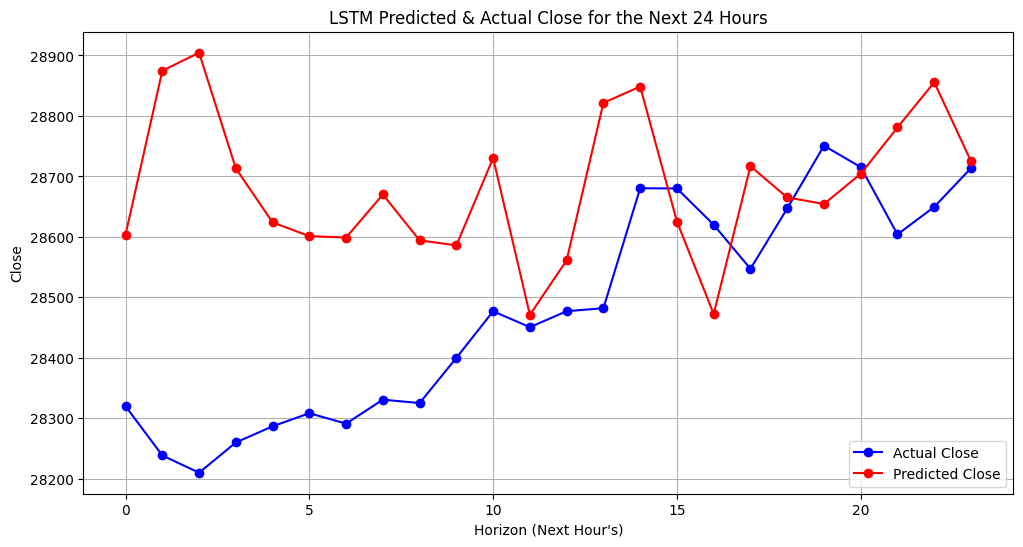

In [42]:
# Visualisasi Hasil
plt.figure(figsize=(12, 6))
plt.plot(y_test_unscaled[-24:], 'bo-', label='Actual Close')
plt.plot(predictions_lstm_unscaled[-24:], 'ro-', label='Predicted Close')
plt.title('LSTM Predicted & Actual Close for the Next 24 Hours')
plt.ylabel('Close')
plt.xlabel("Horizon (Next Hour's)")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
y_true = y_test_unscaled[-24:]
y_pred = predictions_lstm_unscaled[-24:]

# Menggunakan pemrosesan vektor langsung
lstm_comparison_df = pd.DataFrame({
    "Jam ke": range(1, 25),
    "Data Aktual": y_true,
    "Hasil Prediksi": y_pred,
    "Selisih": y_pred - y_true  # Sama dengan -(y_true - y_pred)
})

lstm_comparison_df.head(24)

,Jam ke,Data Aktual,Hasil Prediksi,Selisih
0,1,28319.999254,28603.643850,283.644596
1,2,28238.529298,28874.794825,636.265527
2,3,28209.999206,28904.577400,694.578194
3,4,28259.999051,28713.339555,453.340505
4,5,28286.749913,28623.958664,337.208751
5,6,28308.379640,28601.283250,292.903609
6,7,28291.149213,28598.992883,307.843670
7,8,28330.820945,28670.121070,339.300125
8,9,28325.210131,28594.271683,269.061552
9,10,28400.009930,28585.941302,185.931373


## Sequence to Sequence Model

In [44]:
def predict_sequence(input_seq, encoder_model, decoder_model, horizon):
    # 1. Dapatkan initial state dari encoder
    states_value = encoder_model.predict(input_seq)

    # 2. Ambil nilai terakhir dari urutan input sebagai token awal untuk decoder
    last_value = input_seq[0, -1, 0]
    target_seq = np.array([[[last_value]]]) # Shape: (1, 1, 1)

    # 3. List untuk menyimpan hasil prediksi
    output_sequence = []

    # 4. Loop autoregressive untuk memprediksi sebanyak `horizon`
    for _ in range(horizon):
        # Prediksi satu langkah ke depan
        output_token, h, c = decoder_model.predict(
            [target_seq] + states_value,
            verbose=0 # Matikan log prediksi di dalam loop
        )

        # Simpan hasil prediksi (hanya nilainya)
        output_sequence.append(output_token[0, 0, 0])

        # Update input untuk langkah berikutnya:
        target_seq = output_token
        states_value = [h, c]

    return np.array(output_sequence)

In [45]:
# Dapatkan jumlah unit LSTM dari layer yang sudah ada
lstm_units = seq2seq_model.get_layer('encoder_lstm').units

# Membangun Encoder Model untuk Inference
encoder_input = seq2seq_model.inputs[0]
encoder_output, state_h_encoder, state_c_encoder = seq2seq_model.get_layer('encoder_lstm').output
encoder_states = [state_h_encoder, state_c_encoder]
encoder_model = tf.keras.models.Model(encoder_input, encoder_states)

In [46]:
# Membangun Decoder Model untuk Inference
decoder_state_input_h = tf.keras.layers.Input(shape=(lstm_units,), name='decoder_state_h_input')
decoder_state_input_c = tf.keras.layers.Input(shape=(lstm_units,), name='decoder_state_c_input')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Input untuk decoder hanya 1 langkah waktu
decoder_input_single = tf.keras.layers.Input(shape=(1, 1), name='decoder_input_single')

decoder_lstm = seq2seq_model.get_layer('decoder_lstm')

decoder_outputs, state_h_dec, state_c_dec = decoder_lstm(
    decoder_input_single, initial_state=decoder_states_inputs
)
decoder_states = [state_h_dec, state_c_dec]

# Ambil output layer yang sudah terlatih dan hubungkan
output_layer = seq2seq_model.get_layer('output')
decoder_output_pred = output_layer(decoder_outputs)

In [47]:
# Gabungkan menjadi model decoder final
decoder_model = tf.keras.models.Model(
    [decoder_input_single] + decoder_states_inputs,
    [decoder_output_pred] + decoder_states
)

In [48]:
# Ambil satu batch dari data test untuk demonstrasi
for (encoder_in, decoder_in), decoder_target in test_ds_multi.take(1):
    sample_encoder_input = encoder_in[0:1] # Ambil sampel pertama, shape: (1, 300, 8)
    sample_decoder_target = decoder_target[0] # Target sebenarnya, shape: (5, 1)

# Lakukan prediksi menggunakan fungsi yang sudah kita buat
seq_predicted_sequence_scaled = predict_sequence(sample_encoder_input, encoder_model, decoder_model, HORIZON)

n_samples = len(seq_predicted_sequence_scaled)
target_col_idx = 0 

# 1. Buat array dummy
dummy_pred = np.zeros((n_samples, 8))
dummy_actual = np.zeros((len(sample_decoder_target), 8))

# 2. Gunakan np.ravel() agar kompatibel dengan EagerTensor maupun NumPy array
dummy_pred[:, target_col_idx] = np.ravel(seq_predicted_sequence_scaled)
dummy_actual[:, target_col_idx] = np.ravel(sample_decoder_target)

# 3. Lakukan inverse_transform
seq_predicted_unscaled = scaler.inverse_transform(dummy_pred)[:, target_col_idx]
seq_actual_unscaled = scaler.inverse_transform(dummy_actual)[:, target_col_idx]

print(f"Unscaled Predicted Close: {seq_predicted_unscaled}")
print(f"Unscaled Actual Close: {seq_actual_unscaled}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Unscaled Predicted Close: [30143.13142385 30201.45189449 30201.51042176 30194.98268058
 30187.31560861 30180.41524383 30176.12129334 30176.31248241
 30182.49296181 30195.54454234 30215.62719855 30242.25320321
 30274.45100368 30310.93104919 30350.25942169 30390.98659588
 30431.75278824 30471.36404253 30508.79808249 30543.24333001
 30574.0852488  30600.89073708 30623.3866676  30641.43257492]
Unscaled Actual Close: [30098.91992638 30246.30914281 30060.38947562 30194.2198752
 30127.98066534 30207.5699448  30230.23950621 30130.01936514
 30164.2305036  30189.52013566 30263.75026837 30200.41986368
 30224.78086311 30170.79921386 29916.1607316  29922.04077102
 29978.58006183 29920.00012031 29932.88977541 29987.00018464
 29914.97067717 30007.67981898 29996.27090373 30016.3008854 ]


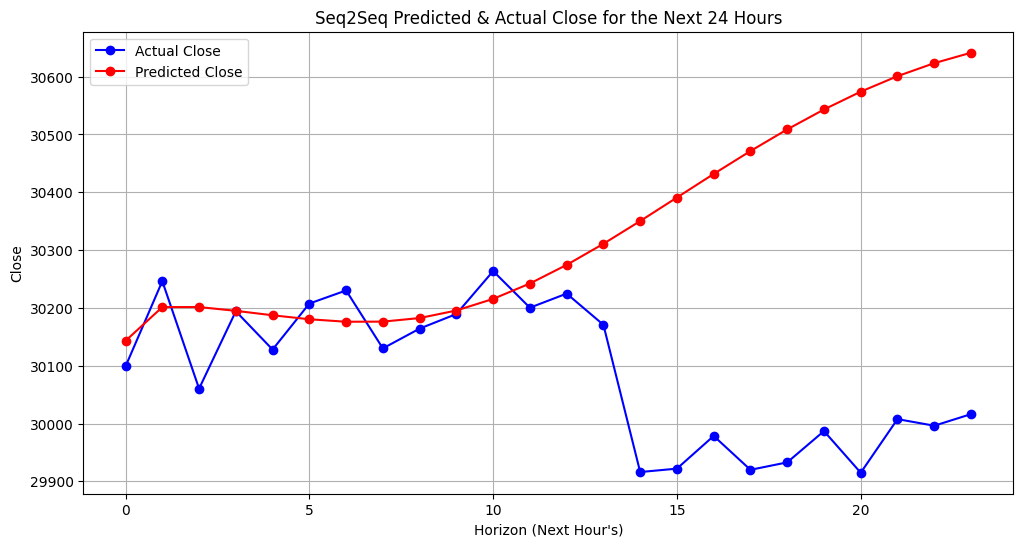

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(seq_actual_unscaled, 'bo-', label='Actual Close')
plt.plot(seq_predicted_unscaled, 'ro-', label='Predicted Close')
plt.title('Seq2Seq Predicted & Actual Close for the Next 24 Hours')
plt.ylabel('Close')
plt.xlabel("Horizon (Next Hour's)")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
seq2seq_y_true = seq_actual_unscaled
seq2seq_y_pred = seq_predicted_unscaled

seq2seq_comparison_table = {
    "Jam ke": range(1, 25),
    "Data Aktual": seq2seq_y_true,
    "Hasil Prediksi": seq2seq_y_pred,
    "Selisih": seq2seq_y_true - seq2seq_y_pred
}

seq2seq_comparison_df = pd.DataFrame(seq2seq_comparison_table)

seq2seq_comparison_df.head(24)

,Jam ke,Data Aktual,Hasil Prediksi,Selisih
0,1,30098.919926,30143.131424,-44.211497
1,2,30246.309143,30201.451894,44.857248
2,3,30060.389476,30201.510422,-141.120946
3,4,30194.219875,30194.982681,-0.762805
4,5,30127.980665,30187.315609,-59.334943
5,6,30207.569945,30180.415244,27.154701
6,7,30230.239506,30176.121293,54.118213
7,8,30130.019365,30176.312482,-46.293117
8,9,30164.230504,30182.492962,-18.262458
9,10,30189.520136,30195.544542,-6.024407


# **Save the Models**

In [51]:
lstm_model.save("model_baseline_LSTM.keras")
seq2seq_model.save("model_seq2seq_LSTM.keras")
print("Model Saved")

Model Saved
